Konteks Dataset E-Commerce

Dataset ini berasal dari transaksi sebuah toko retail online di Inggris (UK-based online retail) yang menjual berbagai produk (hadiah, dekorasi, dll).

Dataset ini sering disebut:
“Online Retail Dataset” dari platform Kaggle

Gambaran Umum Data
Periode: sekitar 2010–2011
Tipe data: transactional data (data transaksi penjualan)
Setiap baris = 1 item dalam 1 transaksi

Jadi:
1 invoice bisa punya banyak baris (karena banyak produk dibeli)
 Struktur Data (Makna Variabel)

Berikut penjelasan tiap kolom:
1. InvoiceNo
Nomor transaksi
Bisa sama untuk beberapa baris
Kalau diawali huruf “C” → artinya cancel/refund
2. StockCode
Kode unik produk
Digunakan untuk identifikasi barang
3. Description
Nama produk
Berupa teks (string)
Kadang kosong → ini penting untuk preprocessing
4. Quantity
Jumlah barang dibeli
Bisa:
Positif → pembelian
Negatif → retur/cancel
5. InvoiceDate
Tanggal & waktu transaksi
Format: datetime
Biasanya perlu diubah (parsing) untuk analisis time series
6. UnitPrice
Harga per item (dalam GBP)
Bisa ada nilai tidak wajar (outlier)
7. CustomerID
ID unik pelanggan
Banyak missing value 
Ini tantangan utama preprocessing
8. Country
Negara asal customer
Mayoritas dari UK, tapi ada negara lain juga

1. Import Library & Load Data
Tujuan: membaca dataset dan melihat struktur awal

In [91]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('data.csv', encoding='ISO-8859-1')

# Lihat data awal
print(df.head())
print(df.info())
print(df.shape)

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non

1. Tampilan 5 Data Pertama (df.head())
InvoiceNo  StockCode  Description                          Quantity \
536365     85123A     WHITE HANGING HEART T-LIGHT HOLDER   6

Maknanya:
Ini adalah 5 baris pertama dataset
Semua baris punya:
InvoiceNo = 536365 → artinya 1 transaksi yang sama
Tapi beda StockCode → berarti 1 transaksi beli banyak produk

Kesimpulan:
Data berbentuk transaksi detail (per item)
1 invoice = banyak baris

Contoh Interpretasi Data Baris 1:
CustomerID: 17850
Produk: WHITE HANGING HEART T-LIGHT HOLDER
Jumlah: 6
Harga: 2.55

Artinya:
Customer membeli:
6 barang
harga per item £2.55
total = 6 × 2.55 = £15.3

2. Informasi Struktur Data (df.info())
Ukuran Data:
RangeIndex: 541909 entries

Artinya:
Ada 541.909 baris data
Dataset cukup besar
Jumlah Kolom:
Data columns (total 8 columns)

Ada 8 variabel:
InvoiceNo
StockCode
Description
Quantity
InvoiceDate
UnitPrice
CustomerID
Country

Missing Value 
Description  → 540455 non-null
CustomerID   → 406829 non-null

Artinya:
Description hilang:
541909 - 540455 = 1.454 data kosong
CustomerID hilang:
541909 - 406829 = 135.080 data kosong (banyak)

Kesimpulan:
CustomerID adalah masalah utama preprocessing

Tipe Data:
float64 → CustomerID, UnitPrice  
int64   → Quantity  
str     → lainnya

Catatan penting:
InvoiceDate masih string 
→ harus diubah ke datetime nanti

3. Bentuk Data (df.shape)
(541909, 8)
Artinya:
541.909 baris
8 kolom

Dataset terdiri dari 541.909 transaksi dengan 8 variabel. Ditemukan adanya missing value terutama pada variabel CustomerID sebesar ±25%, sehingga diperlukan tahap preprocessing untuk memastikan kualitas data sebelum analisis lebih lanjut.

2. Data Understanding (Pahami Data)
Tujuan: memahami karakteristik dataset

Yang dilakukan:
Cek jumlah missing value
Cek statistik deskriptif
Cek jumlah transaksi unik
Cek jumlah customer unik

Insight yang dicari:
Apakah banyak missing?
Ada nilai ekstrem?

In [92]:
# Cek missing value
print(df.isnull().sum())

# Statistik deskriptif
print(df.describe())

# Jumlah transaksi & customer
print("Jumlah Invoice:", df['InvoiceNo'].nunique())
print("Jumlah Customer:", df['CustomerID'].nunique())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -80995.000000  -11062.060000   12346.000000
25%         1.000000       1.250000   13953.000000
50%         3.000000       2.080000   15152.000000
75%        10.000000       4.130000   16791.000000
max     80995.000000   38970.000000   18287.000000
Jumlah Invoice: 25900
Jumlah Customer: 4372


1. Missing Value
Description      1454
CustomerID     135080
Interpretasi:
Description kosong: 1.454 data
CustomerID kosong: 135.080 data (sangat banyak)

Artinya:
Sekitar 25% data tidak punya CustomerID
Data ini tidak bisa dipakai untuk analisis pelanggan
Kesimpulan:
CustomerID = masalah utama 
Harus:
Dihapus → jika analisis customer
Atau dipertahankan → jika fokus ke produk saja

2. Statistik Deskriptif
Quantity
mean = 9.55
min = -80995
max = 80995
Interpretasi:
Rata-rata beli: ±9 item
Tapi:
Ada nilai negatif besar → return/cancel
Ada nilai sangat besar → outlier

Contoh:
-80995 → kemungkinan retur besar
80995 → pembelian tidak wajar

UnitPrice
min = -11062
max = 38970

Interpretasi:
Harga negatif → tidak logis
Harga sangat tinggi → outlier

Artinya:
Data belum bersih
Harus difilter

CustomerID
mean = 15287
min = 12346
max = 18287

Interpretasi:
ID customer dalam range normal
Tidak ada masalah besar selain missing value

3. Distribusi Data (Quartile)
25% = 1
50% = 3
75% = 10
Interpretasi:
Mayoritas pembelian:
kecil (1–10 item)
Data cenderung:
right skewed (condong ke kanan)

4. Jumlah Invoice & Customer
Jumlah Invoice: 25900
Jumlah Customer: 4372
Interpretasi:
Invoice:
Ada 25.900 transaksi unik
Customer:
Ada 4.372 pelanggan unik

Rata-rata transaksi per customer:
25900 / 4372 ≈ 5.9 transaksi/customer
Artinya:
Customer cukup aktif (repeat buyer)

Berdasarkan analisis awal, dataset memiliki 541.909 observasi dengan 8 variabel. Ditemukan missing value yang signifikan pada variabel CustomerID sebesar 135.080 data. Selain itu, terdapat nilai tidak wajar seperti Quantity dan UnitPrice bernilai negatif serta outlier dengan nilai ekstrem. Oleh karena itu, diperlukan tahap preprocessing untuk meningkatkan kualitas data sebelum analisis lebih lanjut.

3. Data Cleaning (Pembersihan Data)

Hapus Missing Value

In [93]:
df = df.dropna(subset=['CustomerID'])
df = df.dropna(subset=['Description'])

Fokus utama:
CustomerID (biasanya banyak kosong)
Description

Strategi:
Drop baris dengan CustomerID kosong

Hapus Duplikasi

In [94]:
df = df.drop_duplicates()

Cek data duplikat
Hapus jika ada

Hapus Transaksi Cancel (InvoiceNo diawali "C")

In [95]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

Ciri:
InvoiceNo diawali "C"
Quantity negatif

Pilihan:
Hapus data cancel → untuk analisis penjualan bersih
ATAU
Pisahkan sebagai analisis retur

Biasanya:
Dihapus untuk preprocessing awal

Filter Nilai Tidak Wajar

In [96]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

Quantity <= 0 → hapus
UnitPrice <= 0 → hapus

4. Data Transformation

Ubah Format Tanggal

In [97]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

Convert InvoiceDate → datetime

Buat Variabel Baru (TotalPrice)

In [98]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

Tambahkan fitur penting:
TotalPrice
TotalPrice = Quantity × UnitPrice
Waktu

Dari InvoiceDate:
Tahun
Bulan
Hari
Jam

Encoding/Ekstrak Waktu

In [99]:
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour

Country → bisa di-encode (label/one-hot)

5. Handling Outlier
Cara:
Menggunakan IQR / Z-score

Fokus:
Quantity
UnitPrice
TotalPrice

Contoh:
Hapus transaksi dengan jumlah terlalu besar (tidak wajar)

In [100]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return df[(df[column] >= lower) & (df[column] <= upper)]

# Terapkan ke kolom penting
df = remove_outliers(df, 'Quantity')
df = remove_outliers(df, 'UnitPrice')
df = remove_outliers(df, 'TotalPrice')

6. Normalisasi / Scaling

Digunakan jika:

Mau lanjut ke ML

Metode:

Min-Max Scaling
Standardization (Z-score)

In [101]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['Quantity', 'UnitPrice', 'TotalPrice']] = scaler.fit_transform(
    df[['Quantity', 'UnitPrice', 'TotalPrice']]
)

7. Data Aggregation (Opsional tapi penting)
Contoh agregasi:
- Per Customer:
Total belanja
Frekuensi transaksi
Rata-rata pembelian

- Per waktu:
Penjualan per bulan
Tren harian

Agregasi per Customer

In [102]:
customer_df = df.groupby('CustomerID').agg({
    'InvoiceNo': 'nunique',
    'Quantity': 'sum',
    'TotalPrice': 'sum'
}).reset_index()

customer_df.columns = ['CustomerID', 'Frequency', 'TotalQuantity', 'Monetary']

print(customer_df.head())

   CustomerID  Frequency  TotalQuantity   Monetary
0     12347.0          7      59.461538  74.221046
1     12348.0          3       5.153846   2.405237
2     12349.0          1      17.461538  25.059148
3     12350.0          1       6.923077   7.850449
4     12352.0          7      16.692308  30.157444


Struktur Data
CustomerID | Frequency | TotalQuantity | Monetary

Artinya:
1 baris = 1 customer
Data sudah diringkas dari transaksi detail menjadi ringkasan perilaku pelanggan
Penjelasan Tiap Kolom

1. CustomerID
12347.0, 12348.0, ...
ID unik pelanggan

2. Frequency
7, 3, 1, ...
Jumlah transaksi (invoice unik) yang dilakukan customer
Contoh:
Customer 12347 → transaksi 7 kali
Customer 12349 → hanya 1 kali

Insight:
Semakin tinggi → customer semakin loyal

3. TotalQuantity
59.46, 5.15, 17.46, ...
Total jumlah barang yang dibeli (sudah dinormalisasi)
Contoh:
Customer 12347 → beli banyak barang
Customer 12348 → beli sedikit
Catatan:
Angka desimal muncul karena sudah melakukan scaling (normalisasi)

4. Monetary
74.22, 2.40, 25.05, ...
Total uang yang dibelanjakan customer
Sama seperti Quantity:
Sudah dalam bentuk scaled (bukan nilai asli)

Contoh Interpretasi Baris
Customer 12347
Frequency = 7
TotalQuantity = 59.46
Monetary = 74.22
Artinya:
Sering belanja (7x)
Beli banyak barang
Pengeluaran tinggi
Kesimpulan:
Customer bernilai tinggi (loyal + profitable)

Customer 12348
Frequency = 3
TotalQuantity = 5.15
Monetary = 2.40
Artinya:
Kadang belanja
Jumlah sedikit
Pengeluaran kecil
Kesimpulan:
Customer biasa

Customer 12349 / 12350
Frequency = 1
Artinya:
Hanya belanja 1 kali
Kesimpulan:
One-time buyer / tidak loyal

Data agregasi menunjukkan bahwa setiap pelanggan memiliki karakteristik berbeda berdasarkan frekuensi transaksi, jumlah pembelian, dan total pengeluaran. Beberapa pelanggan memiliki frekuensi tinggi dengan nilai transaksi besar yang menunjukkan loyalitas tinggi, sementara sebagian lainnya hanya melakukan satu kali transaksi.

Agregasi per Bulan

In [103]:
monthly_sales = df.groupby(['Year', 'Month'])['TotalPrice'].sum().reset_index()

print(monthly_sales.head())

   Year  Month   TotalPrice
0  2010     12  5895.954825
1  2011      1  5059.486386
2  2011      2  4825.838929
3  2011      3  6407.564895
4  2011      4  5410.670285


Struktur Data
Year | Month | TotalPrice

Artinya:
1 baris = total penjualan dalam 1 bulan
Data sudah diringkas dari ribuan transaksi

Penjelasan Tiap Kolom
1. Year (Tahun)
2010, 2011
Tahun terjadinya transaksi

2. Month (Bulan)
12, 1, 2, 3, 4
Bulan transaksi:
12 = Desember
1 = Januari
dst

3. TotalPrice
5895.95, 5059.48, ...
Total nilai penjualan dalam bulan tersebut

Catatan:
Nilai ini sudah hasil penjumlahan semua transaksi
Kemungkinan sudah dinormalisasi (scaled)

Interpretasi Data
Desember 2010
5895.95
Penjualan cukup tinggi

Januari – Februari 2011
5059 → 4825
Terjadi penurunan penjualan

Maret 2011
6407 (tertinggi)
Penjualan naik signifikan

April 2011
5410
Sedikit turun dari Maret
→ tapi masih stabil

Berdasarkan agregasi data bulanan, terlihat bahwa total penjualan mengalami fluktuasi dari Desember 2010 hingga April 2011. Penjualan tertinggi terjadi pada Maret 2011, sedangkan penurunan terjadi pada awal tahun 2011. Pola ini mengindikasikan adanya pengaruh musiman terhadap aktivitas penjualan.

8. Feature Engineering (Advanced)
Contoh:
- RFM Analysis:
Recency → terakhir belanja
Frequency → jumlah transaksi
Monetary → total uang

Ini sering dipakai untuk:
Segmentasi pelanggan

In [104]:
import datetime as dt

# Ambil tanggal terakhir
latest_date = df['InvoiceDate'].max()

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (latest_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print(rfm.head())

   CustomerID  Recency  Frequency   Monetary
0     12347.0        1          7  74.221046
1     12348.0      248          3   2.405237
2     12349.0       18          1  25.059148
3     12350.0      309          1   7.850449
4     12352.0       35          7  30.157444


Struktur Data
CustomerID | Recency | Frequency | Monetary
Artinya:
1 baris = 1 customer
Data menggambarkan perilaku belanja pelanggan
Penjelasan Tiap Variabel
1. CustomerID
ID unik pelanggan

2. Recency
1, 248, 18, 309, ...
Jarak waktu sejak terakhir belanja (dalam hari)

Interpretasi:
Semakin kecil → semakin baru belanja → semakin aktif
Semakin besar → sudah lama tidak belanja

Contoh:
1 → baru saja belanja
309 → sudah lama tidak belanja

3. Frequency
Jumlah transaksi yang dilakukan customer
Interpretasi:
Semakin besar → semakin loyal

4. Monetary
Total uang yang dibelanjakan

Interpretasi:
Semakin besar → semakin bernilai
Interpretasi Tiap Customer
Customer 12347
Recency = 1
Frequency = 7
Monetary = 74.22
Artinya:
Baru saja belanja
Sering transaksi
Pengeluaran tinggi
Kesimpulan:
Customer terbaik (loyal & high value)

Customer 12348
Recency = 248
Frequency = 3
Monetary = 2.40
Artinya:
Sudah lama tidak belanja
Jarang transaksi
Pengeluaran kecil
Kesimpulan:
Customer tidak aktif / hampir churn

Customer 12349
Recency = 18
Frequency = 1
Monetary = 25.05
Artinya:
Relatif baru belanja
Tapi cuma 1x
Pengeluaran lumayan
Kesimpulan:
Customer baru / potensial

Customer 12350
Recency = 309
Frequency = 1
Artinya:
Sudah lama tidak belanja
Tidak loyal
Kesimpulan:
Customer hilang (lost customer)

Customer 12352
Recency = 35
Frequency = 7
Monetary = 30.15
Artinya:
Cukup aktif
Sering transaksi
Nilai sedang
Kesimpulan:
Customer loyal (medium value)

Analisis RFM menunjukkan bahwa pelanggan memiliki karakteristik yang beragam berdasarkan waktu terakhir transaksi, frekuensi pembelian, dan total pengeluaran. Pelanggan dengan nilai recency rendah serta frequency dan monetary tinggi dapat dikategorikan sebagai pelanggan loyal dan bernilai tinggi.

9. Validasi Data

Pastikan:
Tidak ada missing value lagi
Tidak ada nilai aneh
Data sudah konsisten

In [105]:
print(df.isnull().sum())
print(df.describe())

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalPrice     0
Year           0
Month          0
Day            0
Hour           0
dtype: int64
            Quantity                 InvoiceDate      UnitPrice  \
count  319806.000000                      319806  319806.000000   
mean        0.236221  2011-07-12 15:46:29.448415       0.283246   
min         0.000000         2010-12-01 08:26:00       0.000000   
25%         0.038462         2011-04-08 09:45:00       0.126550   
50%         0.153846         2011-08-03 12:10:00       0.219896   
75%         0.423077         2011-10-23 12:46:00       0.393252   
max         1.000000         2011-12-09 12:50:00       1.000000   
std         0.249744                         NaN       0.200137   

          CustomerID     TotalPrice           Year          Month  \
count  319806.000000  319806.000000  319806.000000  319806.000000   
mean    15331.785501    

1. Missing Value (HASIL PALING PENTING)
semua kolom = 0
Interpretasi:
Tidak ada missing value sama sekali
Artinya:
Data sudah bersih 100%
Semua baris valid
Siap untuk analisis lanjutan
Kesimpulan:
Preprocessing berhasil 

2. Jumlah Data Setelah Cleaning
count = 319806
Interpretasi:
Awalnya: 541.909 data
Sekarang: 319.806 data
Artinya:
± 222.000 data dihapus
Kenapa berkurang?
Karena:
Hapus missing CustomerID
Hapus cancel (Quantity negatif)
Hapus outlier
Kesimpulan:
Data sekarang lebih valid & reliable

3. Quantity (SETELAH NORMALISASI)
min = 0
max = 1
mean = 0.236
Interpretasi:
Data sudah di-scaling (Min-Max)
Semua nilai antara 0–1
Artinya:
Tidak ada lagi nilai ekstrem
Sudah siap untuk:
Machine learning

4. UnitPrice
min = 0
max = 1
Sama seperti Quantity:
Sudah dinormalisasi
Tidak ada nilai negatif lagi 

5. TotalPrice
min = 0
max = 1
mean = 0.29
Artinya:
Nilai transaksi sudah:
Bersih
Dinormalisasi
Siap dianalisis

6. CustomerID
range: 12347 – 18287
Artinya:
Semua customer valid
Tidak ada missing lagi

7. Waktu (Year, Month, Day, Hour)
Year
2010 – 2011
Dataset mencakup 2 tahun
Month
mean ≈ 7.65
Rata-rata transaksi terjadi di pertengahan tahun
Day
mean ≈ 15
Transaksi tersebar merata dalam bulan
Hour
mean ≈ 12.7
Artinya:
Transaksi paling sering sekitar jam 12–13 (siang)
Insight:
Jam sibuk = siang hari

8. InvoiceDate
2010-12-01 → 2011-12-09
Artinya:
Rentang data ± 1 tahun
Sudah dalam format datetime (berhasil transformasi)

Setelah dilakukan preprocessing, jumlah data berkurang dari 541.909 menjadi 319.806 observasi. Seluruh variabel telah bebas dari missing value dan nilai tidak wajar. Selain itu, dilakukan normalisasi sehingga seluruh variabel numerik berada pada rentang 0 hingga 1. Data yang telah dibersihkan ini siap digunakan untuk analisis lebih lanjut seperti clustering dan segmentasi pelanggan.

10. Export Data Bersih
Simpan ke Excel baru
Siap untuk:
Visualisasi

In [106]:
with pd.ExcelWriter('hasil_analisis.xlsx') as writer:
    df.to_excel(writer, sheet_name='Data Clean', index=False)
    rfm.to_excel(writer, sheet_name='RFM', index=False)
    monthly_sales.to_excel(writer, sheet_name='Monthly Sales', index=False)

Histogram

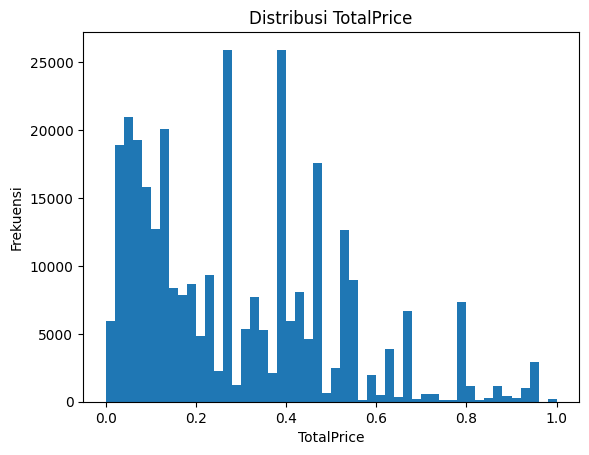

In [107]:
import matplotlib.pyplot as plt

# Histogram TotalPrice
plt.hist(df['TotalPrice'], bins=50)
plt.title('Distribusi TotalPrice')
plt.xlabel('TotalPrice')
plt.ylabel('Frekuensi')
plt.show()

Berdasarkan histogram distribusi TotalPrice, terlihat bahwa data memiliki distribusi yang tidak simetris dan cenderung skew ke kanan. Hal ini menunjukkan bahwa sebagian besar transaksi memiliki nilai yang rendah, sementara hanya sebagian kecil transaksi yang memiliki nilai tinggi. Pola ini umum ditemukan pada data transaksi retail.

Boxplot

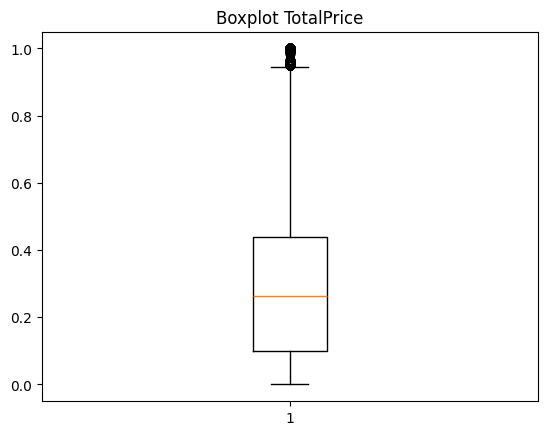

In [108]:
plt.boxplot(df['TotalPrice'])
plt.title('Boxplot TotalPrice')
plt.show()

Berdasarkan hasil boxplot pada variabel TotalPrice, terlihat bahwa median nilai berada pada kisaran tengah, yang menunjukkan bahwa sebagian besar transaksi memiliki nilai total yang relatif sedang. Rentang interkuartil (IQR) menunjukkan bahwa mayoritas data terkonsentrasi pada interval tertentu tanpa penyebaran yang terlalu luas.

Namun, terdapat beberapa titik di atas batas atas (upper whisker) yang menunjukkan adanya outlier. Hal ini mengindikasikan adanya transaksi dengan nilai yang jauh lebih tinggi dibandingkan sebagian besar data lainnya. Selain itu, distribusi data cenderung sedikit miring ke kanan (positively skewed), yang berarti terdapat lebih banyak nilai ekstrem pada sisi atas.

Secara keseluruhan, sebagian besar transaksi memiliki nilai TotalPrice yang moderat, namun terdapat beberapa transaksi bernilai tinggi yang dapat memberikan kontribusi signifikan terhadap total penjualan.

Line Chart

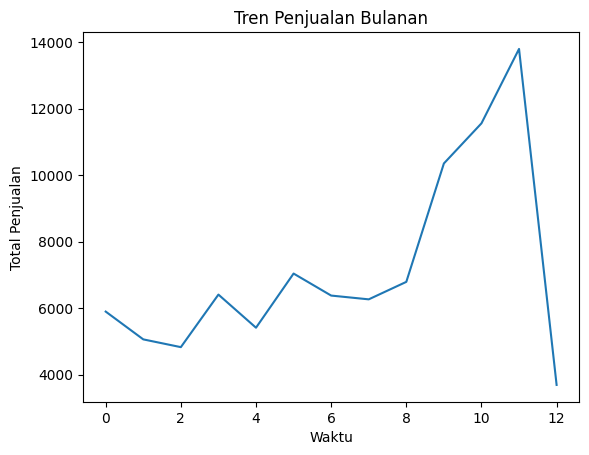

In [109]:
plt.plot(monthly_sales['TotalPrice'])
plt.title('Tren Penjualan Bulanan')
plt.xlabel('Waktu')
plt.ylabel('Total Penjualan')
plt.show()

Berdasarkan grafik tren penjualan bulanan, terlihat bahwa total penjualan mengalami fluktuasi pada periode awal hingga pertengahan, dengan nilai yang relatif stabil di kisaran menengah. Namun, mulai periode selanjutnya terjadi peningkatan yang cukup signifikan, yang ditunjukkan dengan lonjakan penjualan hingga mencapai puncaknya pada periode ke-11.

Setelah mencapai puncak, terjadi penurunan yang sangat tajam pada periode terakhir. Penurunan drastis ini kemungkinan disebabkan oleh faktor musiman, keterbatasan data, atau belum lengkapnya pencatatan pada periode tersebut.

Secara keseluruhan, tren penjualan menunjukkan adanya peningkatan di akhir periode, yang mengindikasikan potensi pertumbuhan penjualan, meskipun terdapat fluktuasi di beberapa periode.

Scatter Plot

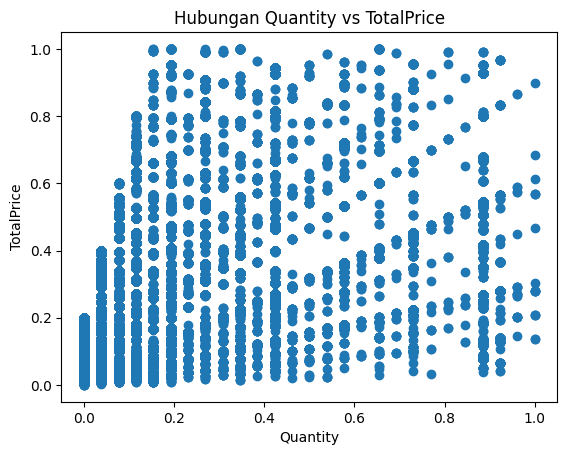

In [110]:
plt.scatter(df['Quantity'], df['TotalPrice'])
plt.xlabel('Quantity')
plt.ylabel('TotalPrice')
plt.title('Hubungan Quantity vs TotalPrice')
plt.show()

Berdasarkan hasil scatter plot antara Quantity dan TotalPrice, terlihat bahwa terdapat kecenderungan hubungan positif antara kedua variabel. Hal ini menunjukkan bahwa semakin banyak jumlah barang yang dibeli, maka total harga yang dihasilkan juga cenderung meningkat.

Namun, pola sebaran data terlihat cukup menyebar dan tidak membentuk garis linear yang jelas, yang mengindikasikan bahwa hubungan antara Quantity dan TotalPrice tidak sepenuhnya kuat. Hal ini dapat disebabkan oleh adanya variasi harga satuan (UnitPrice) pada setiap transaksi. Selain itu, terlihat bahwa pada nilai Quantity rendah, TotalPrice cenderung berada pada nilai yang rendah, sedangkan pada Quantity yang lebih tinggi, nilai TotalPrice menjadi lebih bervariasi.

RFM Scatter Plot

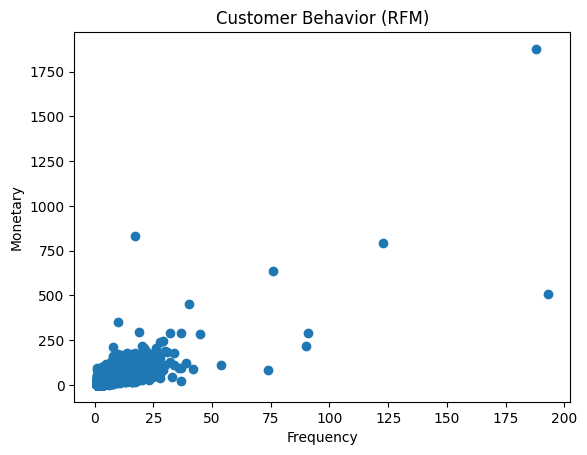

In [111]:
plt.scatter(rfm['Frequency'], rfm['Monetary'])
plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.title('Customer Behavior (RFM)')
plt.show()

Berdasarkan hasil visualisasi scatter plot antara variabel Frequency dan Monetary, terlihat bahwa sebagian besar pelanggan berada pada kelompok dengan frekuensi transaksi rendah dan nilai pembelian yang kecil. Hal ini menunjukkan bahwa mayoritas pelanggan belum memberikan kontribusi signifikan terhadap pendapatan. Namun, terdapat beberapa pelanggan dengan frekuensi dan nilai pembelian yang tinggi, yang dapat dikategorikan sebagai pelanggan bernilai tinggi. Selain itu, ditemukan variasi perilaku pelanggan, seperti pelanggan yang sering bertransaksi dengan nilai kecil maupun pelanggan yang jarang bertransaksi tetapi dengan nilai besar. Secara umum, pola hubungan antara Frequency dan Monetary menunjukkan kecenderungan positif, di mana peningkatan frekuensi transaksi cenderung diikuti oleh peningkatan nilai pembelian. Namun, hubungan tersebut tidak bersifat linear sempurna karena terdapat variasi perilaku pelanggan yang cukup beragam.

Heatmap Korelasi

<Axes: >

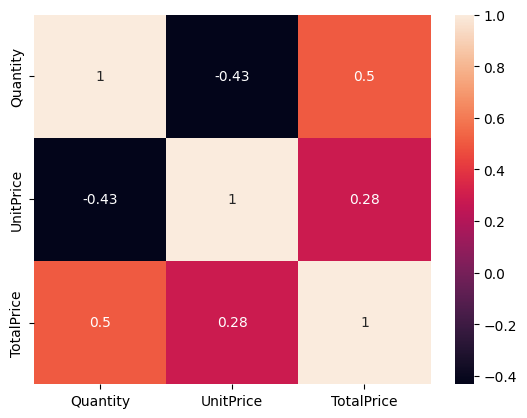

In [112]:
import seaborn as sns

corr = df[['Quantity','UnitPrice','TotalPrice']].corr()
sns.heatmap(corr, annot=True)

Berdasarkan hasil visualisasi heatmap korelasi, terlihat hubungan antar variabel Quantity, UnitPrice, dan TotalPrice. Variabel Quantity memiliki korelasi positif sedang dengan TotalPrice sebesar 0,5, yang menunjukkan bahwa semakin banyak jumlah barang yang dibeli, maka total harga cenderung meningkat. Sementara itu, UnitPrice memiliki korelasi positif lemah dengan TotalPrice sebesar 0,28, yang mengindikasikan bahwa harga satuan juga berkontribusi terhadap total harga, namun tidak terlalu kuat.

Di sisi lain, terdapat korelasi negatif antara Quantity dan UnitPrice sebesar -0,43, yang menunjukkan bahwa semakin tinggi jumlah pembelian, harga satuan cenderung lebih rendah. Hal ini dapat mengindikasikan adanya diskon atau harga grosir pada pembelian dalam jumlah besar. Secara keseluruhan, TotalPrice lebih dipengaruhi oleh Quantity dibandingkan UnitPrice.